In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
import seaborn as sns

In [ ]:
df = pd.read_csv(
    "climate-deforestation-merged.csv"
)


In [ ]:
df = pd.read_csv("climate-deforestation-merged.csv")

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

# Opcjonalnie: wykluczenie identyfikatorów
exclude_cols = ["Year", "Month"]  # dostosuj do swoich potrzeb
numeric_cols = [col for col in numeric_cols if col not in exclude_cols]

# Standaryzacja Z-score
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Zapis do nowego pliku
df.to_csv("climate-deforestation-merged-standardized.csv", index=False)

print("Standaryzacja zakończona.")
print(df.head())

Standaryzacja zakończona.
   Year  Month State  Deforestation_ha  CO2_Emissions  Total_Precipitation  \
0  2003      2    SE         -0.419469      -0.403340            -0.230372   
1  2003      3    SE         -0.419469      -0.403340            -0.312053   
2  2003      4    SE         -0.414785      -0.401209            -0.260840   
3  2003      5    SE         -0.391365      -0.390557             0.398437   
4  2003      6    SE         -0.358577      -0.375642             0.157934   

   Atmospheric_Pressure_Station  Global_Radiation  Air_Temperature  \
0                      0.733114          0.057405         0.863718   
1                      0.719180         -0.062917         0.866642   
2                      0.735217         -0.260349         0.872490   
3                      0.763874         -0.160370         0.468992   
4                      0.804099         -0.097073         0.205841   

   Max_Air_Temperature  Min_Air_Temperature  Relative_Humidity  \
0             0.68

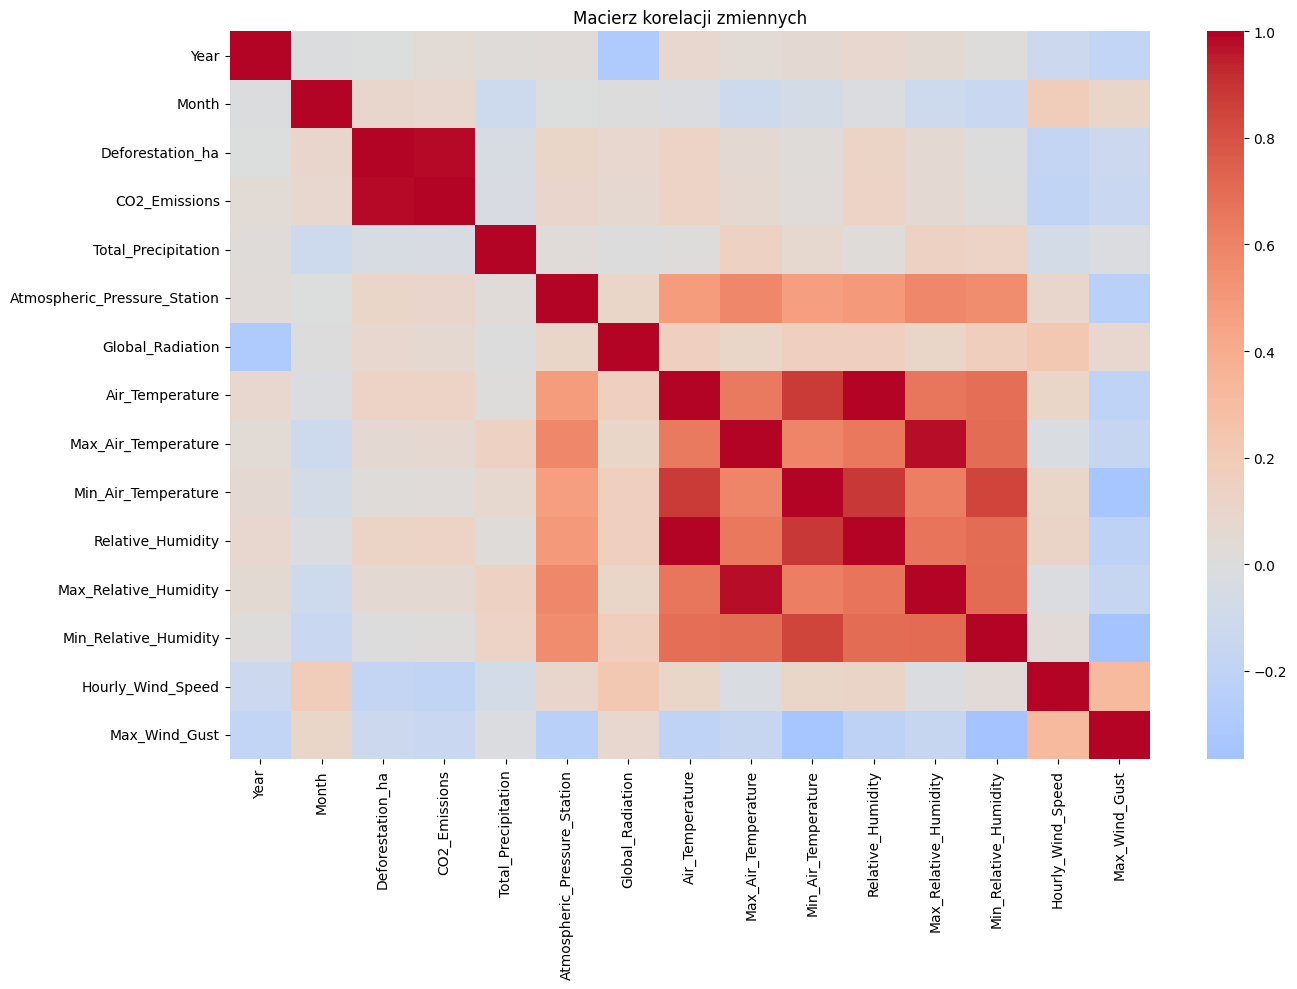

In [ ]:

# Wczytanie danych
df = pd.read_csv("climate-deforestation-merged.csv")

# Tylko kolumny numeryczne
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Macierz korelacji
corr_matrix = numeric_df.corr()

# Heatmapa
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Macierz korelacji zmiennych")
plt.tight_layout()
plt.show()